Hola **Juan**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

# CallMeMaybe : Identificación de Operadores Ineficaces
___

Proyecto final - Entrega del proyecto

**Objetivo**

La empresa de telecomunicaciones *CallMeMaybe* trabajando constantemente en el desarrollo de herramientas para que su personal tenga visibilidad de indicadores de rendimiento en el área de servicio al cliente. 

Ultimante las encuestas aleatorias de satisfación del cliente han arrojado información en las que las evaluaciones del área ha decaido en un 28% con respecto al trimestre anterior y estos resultados han encendido alertas que el equipo gerencial quiere atender para mejorar ese indicador. Dentro de los requerimeintos que nos han solicitado es identificar a los operadores menos eficaces del equipo ya que una posibilidad es que el servicio brindado por ellos es lo que afectan las evaluaciones del área.

La empresa considera que un operador es ineficaz si cumple estos parámetros:

     - Tiene una gran cantidad de llamadas entrantes perdidas (internas y externas).
     - Tiene un tiempo de espera prolongado para las llamadas entrantes. 
     - Tiene un número reducido de llamadas salientes.

**Descripción de los datos**

Los datasets contienen información sobre el uso del servicio de telefonía virtual CallMeMaybe. Sus clientes son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores. Los operadores también pueden realizar llamadas internas para comunicarse entre ellos. Estas llamadas se realizan a través de la red de CallMeMaybe.

El dataset comprimido `telecom_dataset_us.csv` contiene las siguientes columnas:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

  
El conjunto de datos `telecom_clients_us.csv` tiene las siguientes columnas:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

### Entregables

#### Dashborad

https://public.tableau.com/app/profile/juan.carlos.vertiz.mill.m/viz/CallMeMaybeAnlisisExploratoriodeLlamadas/Dashboard1?publish=yes

#### Presentación

https://drive.google.com/file/d/1H39ym7PSDtjuT7hCjJlbLenuVHASwT1P/view?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La presentación final de tu proyecto debe ser los resultados resumidos pero específicos, deberías apoyarte en los resultados obtenidos en tu notebook ya sean numéricos o gráficos para dejar una presentación correcta.

Imagina que vas a exponer el resultado de tu notebook ante un grupo de personas de negocio que desean ver tus resultados del análisis.
</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
    Gracias Patricio, ya se actualizó la liga del informe
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, de esta forma el documento comunica muy bien los hallazgos argumentado cada punto con datos y los resultados de tu análisis.

Cómo profesional en datos la comunicación es un skill muy importante para llevar nuestros resultados ante las personas interesadas de manera efectiva, buen trabajo!
</div>

In [1]:
#Se cargan las librerias a utilizar

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats

## Parte 1. Cargar datos

In [2]:
#Se cargan los datasets

telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [3]:
#Se revisa la información contenido en los datasets

display(telecom.info())
telecom.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


None

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [4]:
telecom.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [5]:
#Se buscan valores ausentes

telecom.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [6]:
#Se buscan valores duplicados

telecom.duplicated().sum()

4900

In [7]:
#Se visualizan las filas duplicadas. Se mantiene la primera ocurrencia

filas_duplicadas = telecom[telecom.duplicated(keep=False)]
print(f"Total de filas duplicadas: {len(filas_duplicadas)}")
filas_duplicadas.head(10) 

Total de filas duplicadas: 9800


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
43,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3
46,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473


Dentro de la información proporcionada, encontramos 4,900 registros duplicados. Esto representa aproximandamene el **9.1%** de la información.

Al realizar el análisis, podemos decir que estos NO son errores de datos, sino registros legítimos que se repiten. 

Por represntar el **9.1%** de la información del listado **no** se eliminaron los duplicados por las siguientes razones:

- Representan eventos reales:

        En telecomunicaciones, es común tener múltiples llamadas en el mismo momento
        Pueden ser llamadas grupales, conferencias, o intentos múltiples

- Impacto estadístico significativo:

        4,900 registros = 9.1% de tus datos
        Eliminarlos podría sesgar tus análisis de eficacia de operadores

- Para el objetivo del proyecto:

        Se estan identificando operadores ineficaces
        Estas llamadas repetidas podrían ser indicadores importantes de problemas operacionales

In [8]:
#Se cambia el formato de la columna date

telecom['date'] = pd.to_datetime(telecom['date'], format= '%Y-%m-%dT%H:%M:%S')
telecom['date'] = telecom['date'].dt.tz_convert('UTC')

#Se crean nuevas columnas de fecha

telecom['year'] = telecom['date'].dt.year
telecom['month'] = telecom['date'].dt.month
telecom['day'] = telecom['date'].dt.day

#Se convierte la columna del operator_id
telecom['operator_id'] = telecom['operator_id'].astype('Int64')

In [9]:
#Se revisa la información actualizada del dataset

display(telecom.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   user_id              53902 non-null  int64              
 1   date                 53902 non-null  datetime64[ns, UTC]
 2   direction            53902 non-null  object             
 3   internal             53785 non-null  object             
 4   operator_id          45730 non-null  Int64              
 5   is_missed_call       53902 non-null  bool               
 6   calls_count          53902 non-null  int64              
 7   call_duration        53902 non-null  int64              
 8   total_call_duration  53902 non-null  int64              
 9   year                 53902 non-null  int64              
 10  month                53902 non-null  int64              
 11  day                  53902 non-null  int64              
dtypes: Int64(1), bool(

None

In [10]:
#Se calcula el hold time y se reordenan columnas

telecom['hold_time'] = telecom['total_call_duration'] - telecom['call_duration']
columns_order = ['user_id', 'date', 'year', 'month', 'day', 'direction', 
                     'internal', 'operator_id', 'is_missed_call', 'calls_count', 
                     'call_duration', 'hold_time', 'total_call_duration']

telecom = telecom[columns_order]
telecom.head()

,user_id,date,year,month,day,direction,internal,operator_id,is_missed_call,calls_count,call_duration,hold_time,total_call_duration
0,166377,2019-08-03 21:00:00+00:00,2019,8,3,in,False,<NA>,True,2,0,4,4
1,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880022,True,3,0,5,5
2,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880020,True,1,0,1,1
3,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880020,False,1,10,8,18
4,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,False,880022,True,3,0,25,25



Dentro de la información de las llamadas identificamos 117 valores faltantes en la columna de *internal* y 8,172 valores faltantes en la columna de *operator_id*.

Esto es lo que encontramos y podemos inferir en el caso de las llamadas *internal*:

 - Todas son llamadas entrantes (direction = 'in')
 - Esto sugiere que el sistema no pudo determinar si la llamada era interna o externa
 - Posiblemente son llamadas desde números no identificados o sistemas externos

Por ser valores reales no se pueden eliminar y se le colocará la categoria *unknown* para poder identificarlas e incluirlas en algún escenario futuro del analisis.

En el caso de la información faltante de la columna *operator_id*, podemos decir:

 - Todas son llamadas entrantes (direction = 'in')
 - Todas tienen internal = False
 - Esto indica llamadas externas entrantes que no fueron atendidas por ningún operador específico

Los valores faltantes de esta columna son llamadas externas que llegaron al sistema pero no fueron asignadas a operadores, este un valor alto de llamada sin atender, esto puede representar un problema de eficiencia que la empresa podría resolver. También se podria analizar si son en dias y horas en especifico para determinar si no hay suficientes agentes conectados o se puede deber a otra razón. 

Como el caso de las llamadas *internal*, a las llamadas sin *operator_id* se lse colocará un operator_id *0* para poder identificarlas e incluirlas en algún escenario futuro del analisis.




In [11]:
#Se completa la información faltante

telecom['internal'] = telecom['internal'].fillna('unknown')
telecom['operator_id'] = telecom['operator_id'].fillna(0)

In [12]:
#Se revisa la información actualizada del dataset

display(telecom.info())
telecom.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   user_id              53902 non-null  int64              
 1   date                 53902 non-null  datetime64[ns, UTC]
 2   year                 53902 non-null  int64              
 3   month                53902 non-null  int64              
 4   day                  53902 non-null  int64              
 5   direction            53902 non-null  object             
 6   internal             53902 non-null  object             
 7   operator_id          53902 non-null  Int64              
 8   is_missed_call       53902 non-null  bool               
 9   calls_count          53902 non-null  int64              
 10  call_duration        53902 non-null  int64              
 11  hold_time            53902 non-null  int64              
 12  total_call_duratio

None

,user_id,date,year,month,day,direction,internal,operator_id,is_missed_call,calls_count,call_duration,hold_time,total_call_duration
0,166377,2019-08-03 21:00:00+00:00,2019,8,3,in,False,0,True,2,0,4,4
1,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880022,True,3,0,5,5
2,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880020,True,1,0,1,1
3,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,True,880020,False,1,10,8,18
4,166377,2019-08-04 21:00:00+00:00,2019,8,4,out,False,880022,True,3,0,25,25


In [13]:
#Se revisa la información actualizada del dataset

telecom.isna().sum()

user_id                0
date                   0
year                   0
month                  0
day                    0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
hold_time              0
total_call_duration    0
dtype: int64

In [14]:
#Se revisa la información contenido en los datasets

display(clients.info())
clients.head()
clients['tariff_plan'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


None

array(['A', 'C', 'B'], dtype=object)

In [15]:
clients.describe()

,user_id
count,732.000000
mean,167431.927596
std,633.810383
min,166373.000000
25%,166900.750000
50%,167432.000000
75%,167973.000000
max,168606.000000


In [16]:
#Se buscan valores ausentes

clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [17]:
#Se buscan valores duplicados

clients.duplicated().sum()

0

In [18]:
#Se cambia el formato de la columna date_start

clients['date_start'] = pd.to_datetime(clients['date_start'])

#Se crean nuevas columnas de fecha

clients['year'] = clients['date_start'].dt.year
clients['month'] = clients['date_start'].dt.month
clients['day'] = clients['date_start'].dt.day

In [19]:
#Se revisa la información actualizada del dataset

display(clients.info())
clients.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    object        
 2   date_start   732 non-null    datetime64[ns]
 3   year         732 non-null    int64         
 4   month        732 non-null    int64         
 5   day          732 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 34.4+ KB


None

,user_id,tariff_plan,date_start,year,month,day
0,166713,A,2019-08-15,2019,8,15
1,166901,A,2019-08-23,2019,8,23
2,168527,A,2019-10-29,2019,10,29
3,167097,A,2019-09-01,2019,9,1
4,168193,A,2019-10-16,2019,10,16


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el análisis inicial y el tratamiento de los dataset previo a su exploración. Es vital tener los datos limpios y de calidad para que las decisiones que se tomen a partir del EDA sean acertadas y siempre argumentadas en datos.
</div>

## Parte 2. Análisis exploratorio de datos (EDA)

In [20]:
#Se crear un DataFrame con los datos agrupados

calls_data_detailed = telecom.groupby(['direction', 'internal', 'is_missed_call']).size().reset_index(name='count')

calls_data_detailed['categoria'] = calls_data_detailed.apply(
    lambda row: f"{'Exitosas' if not row['is_missed_call'] else 'Perdidas'} {'Internas' if row['internal'] == True else 'Externas' if row['internal'] == False else 'Desconocidas'}", 
    axis=1
)

calls_pivot = calls_data_detailed.pivot_table(
    index='direction', 
    columns='categoria', 
    values='count', 
    fill_value=0
)
calls_pivot

categoria,Exitosas Desconocidas,Exitosas Externas,Exitosas Internas,Perdidas Desconocidas,Perdidas Externas,Perdidas Internas
direction,,,,,,
in,59,12882,401,56,8256,331
out,0,14201,2791,2,12282,2641


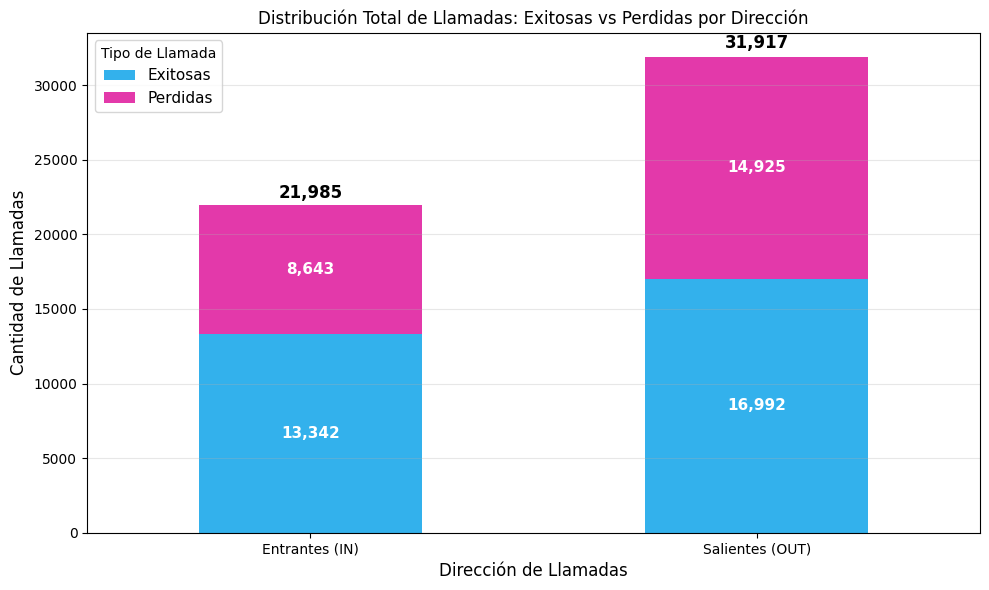

In [21]:
#Se grafican las llamadas entrantes, salienets y se incluyen las exitosas y las perdidas


calls_data = telecom.groupby(['direction', 'is_missed_call']).size().unstack(fill_value=0)
calls_data.columns = ['Exitosas', 'Perdidas']


fig, ax = plt.subplots(figsize=(10, 6))

bars = calls_data.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#009EE8', '#DD0795'], alpha=0.8,
                       title='Distribución Total de Llamadas: Exitosas vs Perdidas por Dirección')

ax.set_xlabel('Dirección de Llamadas', fontsize=12)
ax.set_ylabel('Cantidad de Llamadas', fontsize=12)
ax.set_xticklabels(['Entrantes (IN)', 'Salientes (OUT)'], rotation=0)

totals = calls_data.sum(axis=1)
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, total + total*0.01, f'{int(total):,}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

for i, (direction, row) in enumerate(calls_data.iterrows()):
    ax.text(i, row['Exitosas']/2, f'{int(row["Exitosas"]):,}', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    ax.text(i, row['Exitosas'] + row['Perdidas']/2, f'{int(row["Perdidas"]):,}', 
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.legend(title='Tipo de Llamada', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Al analizar las llamadas por direccion y si fueron exitosas o perdidas encontramos información muy valiosa:

El **39%** de las llamadas entrantes son llamadas perdidas y el **61%** son llamadas exitosas. En el caso de las llamadas salientes la proporción es **47%** de llamadas pedidas y **53%** de llamadas exitosas.

Estos números nos dan un primer vistazo sobre el desempeño de los agentes, las tazas de llamadas perdidas son muy altos al igual que la llamadas salientes. Estos datos nos pueden ir dando una idea de las areas a mejorar de los operadores y del negocio en general. 

Seguiremos haciendo el analisis para identificar patrones y a los operadores ineficaces.

In [22]:
#Se analizan a detalle la eficacia por operador

def analizar_eficacia_operadores():
    real_operators = telecom[telecom['operator_id'] != 0].copy()
    
    metrics_operator = real_operators.groupby('operator_id').agg({
        'is_missed_call': ['count', 'sum'],  
        'calls_count': 'sum',                
        'call_duration': 'sum',              
        'total_call_duration': 'sum',
        'hold_time':'sum'
    }).round(2)
    
    metrics_operator.columns = ['total_registros', 'llamadas_perdidas', 
                                'total_llamadas', 'duracion_llamadas', 'duracion_total', 'total_tiempo_en_espera']
    
    metrics_operator['tasa_perdidas'] = (metrics_operator['llamadas_perdidas'] / 
                                         metrics_operator['total_llamadas'] * 100).round(2)
    
    metrics_operator['tiempo_espera_promedio'] = (
        (metrics_operator['duracion_total'] - metrics_operator['duracion_llamadas']) / 
        metrics_operator['total_registros']
    ).round(2)
    
    return metrics_operator

metrics = analizar_eficacia_operadores()

print("MÉTRICAS DE EFICACIA POR OPERADOR")
print("="*50)
print(f"Total de operadores analizados: {len(metrics)}")
print(f"Promedio tasa de llamadas perdidas: {metrics['tasa_perdidas'].mean():.1f}%")
print(f"Promedio tiempo de espera: {metrics['tiempo_espera_promedio'].mean():.1f} segundos")

print("\nTOP 10 OPERADORES CON MAYOR TASA DE LLAMADAS PERDIDAS:")
top_lost = metrics.nlargest(10, 'tasa_perdidas')[['total_registros', 'llamadas_perdidas', 'tasa_perdidas', 'total_llamadas', 'tiempo_espera_promedio', 'total_tiempo_en_espera']]
top_lost

MÉTRICAS DE EFICACIA POR OPERADOR
Total de operadores analizados: 1092
Promedio tasa de llamadas perdidas: 10.1%
Promedio tiempo de espera: 215.4 segundos

TOP 10 OPERADORES CON MAYOR TASA DE LLAMADAS PERDIDAS:


,total_registros,llamadas_perdidas,tasa_perdidas,total_llamadas,tiempo_espera_promedio,total_tiempo_en_espera
operator_id,,,,,,
885682,3,3,100.0,3,17.0,51
899076,2,2,100.0,2,23.5,47
905480,1,1,100.0,1,5.0,5
914272,1,1,100.0,1,9.0,9
914626,1,1,100.0,1,0.0,0
924572,1,1,100.0,1,1.0,1
928282,2,2,100.0,2,8.0,16
932246,1,1,100.0,1,60.0,60
937710,1,1,100.0,1,15.0,15


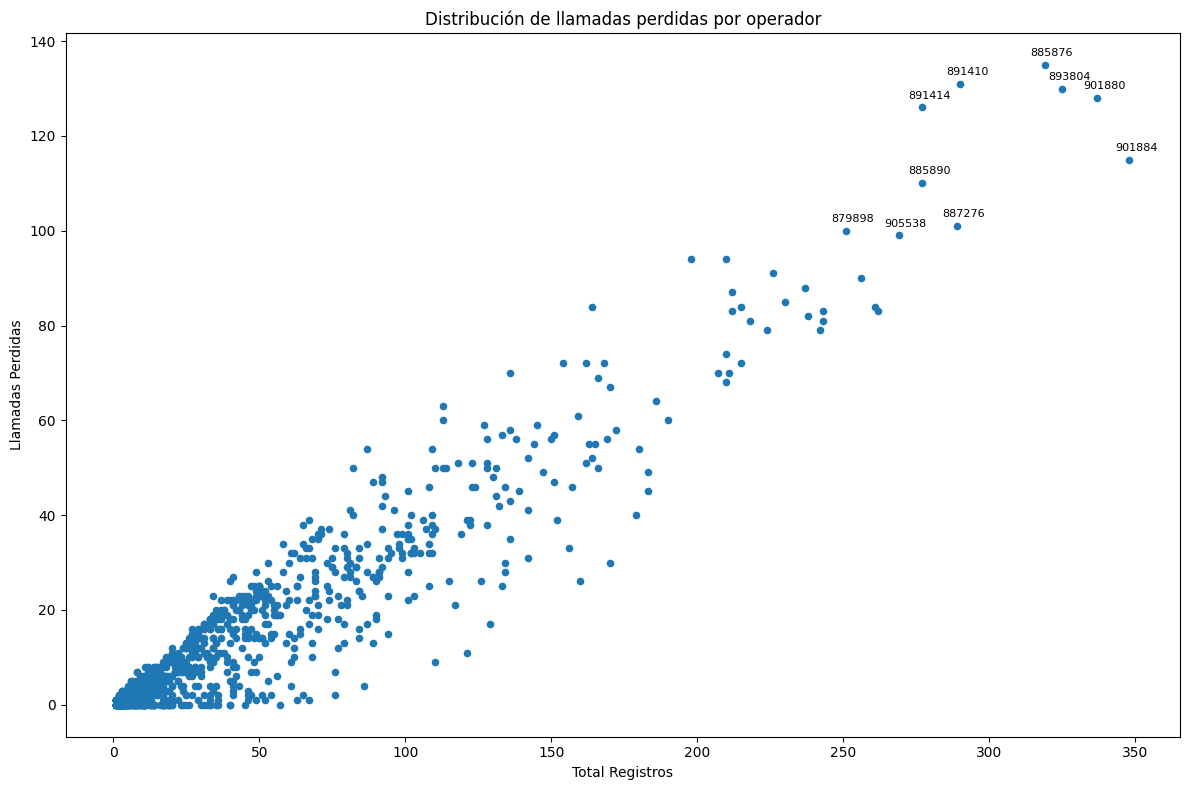

In [23]:
#Se crea grafica de disperción de las llamadas pedidas

fig, ax = plt.subplots(figsize=(12, 8))
metrics.plot(x='total_registros', y='llamadas_perdidas', 
             kind='scatter', ax=ax,
             title='Distribución de llamadas perdidas por operador',
             xlabel='Total Registros',
             ylabel='Llamadas Perdidas')

top_operators = metrics.nlargest(10, 'llamadas_perdidas')

for operador_id in top_operators.index:
    x = top_operators.loc[operador_id, 'total_registros']
    y = top_operators.loc[operador_id, 'llamadas_perdidas']
    plt.annotate(operador_id, (x, y), 
                fontsize=8, ha='center', va='bottom',
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


En este graficp podemos obsevar que algunos operadores que se estan perfilando para entrar dentro de los considerados ineficaces, es muy pronto para asegurarlo. Se seguira analizando la infomración para encontarlos de acuerdo a las metricas de *CallMe Maybe*.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Cada gráfica tiene un objetivo específico y un tipo de explicación que pueden dar, por ejemplo, en este caso la gráfica de dispersión se utiliza con dos variables numéricas para visualizar si existe una correlación por lo cual utilizaste muy bien la gráfica para mostrar ambas variables
</div>

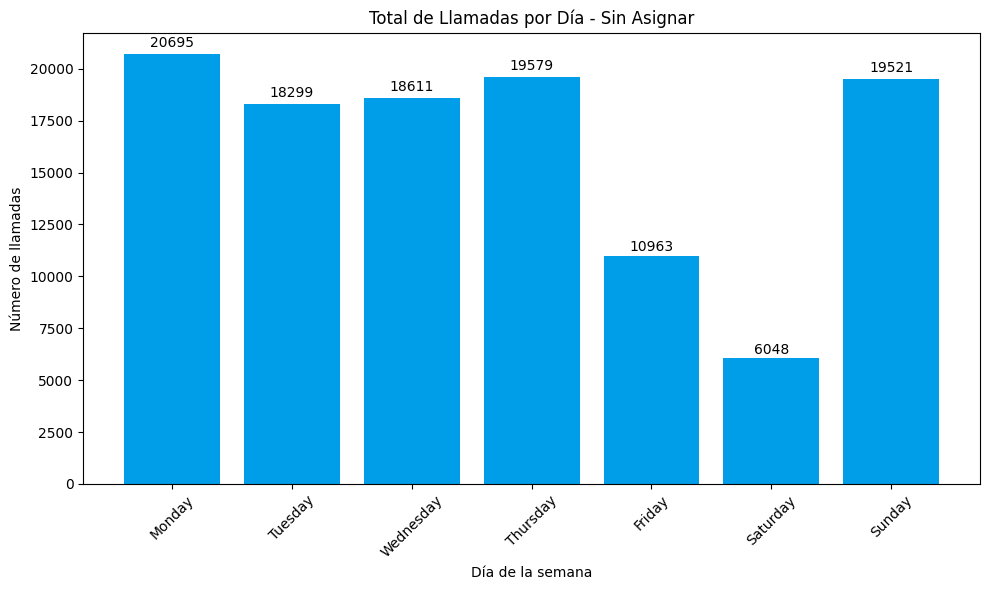

In [24]:
#Se crea gráfica de barras para visualizar concentración de llamadas no asignada

operador_0 = telecom[telecom['operator_id'] == 0].copy()
operador_0['day_of_week'] = operador_0['date'].dt.day_name()
operador_0['hour'] = operador_0['date'].dt.hour

calls_by_day = operador_0.groupby('day_of_week')['calls_count'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
calls_by_day = calls_by_day.reindex(day_order)

calls_grouped = operador_0.groupby(['day_of_week', 'hour'])['calls_count'].sum().reset_index()

calls_grouped['day_of_week'] = pd.Categorical(calls_grouped['day_of_week'], categories=day_order, ordered=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(calls_by_day.index, calls_by_day.values, color='#009EE8')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Total de Llamadas por Día - Sin Asignar')
plt.xlabel('Día de la semana')
plt.ylabel('Número de llamadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Despúes de analizar la información de las llamadas no asigandas podemos observar que los días lunes, jueves y domingo con los días que concentran mayor cantidad de llamadas no atendidads a las 21 horas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí sería más recomendable hacerlo con una gráfica de barras ya que si lo notas tienes pocos datos para los días y sólo tienes una cantidad para cada día por lo que el contraste se vería mejor en gráfica de barras. Una gráfica tipo mapa de calor es mejor cuando tienes resultados tipo matriz cómo los que se obtienen al hacer uso de `pivot_table`
</div>

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>

Gracias Patricio por tu feedback, se hicieron los ajustes para mostrar la concentración de llamadas sin asignar por día en una gráfica de barra para poder visualizarla facilmente.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho los cambios! Siempre una correcta visualización es clave para comunicar de manera adecuada la idea de un resultado
</div>

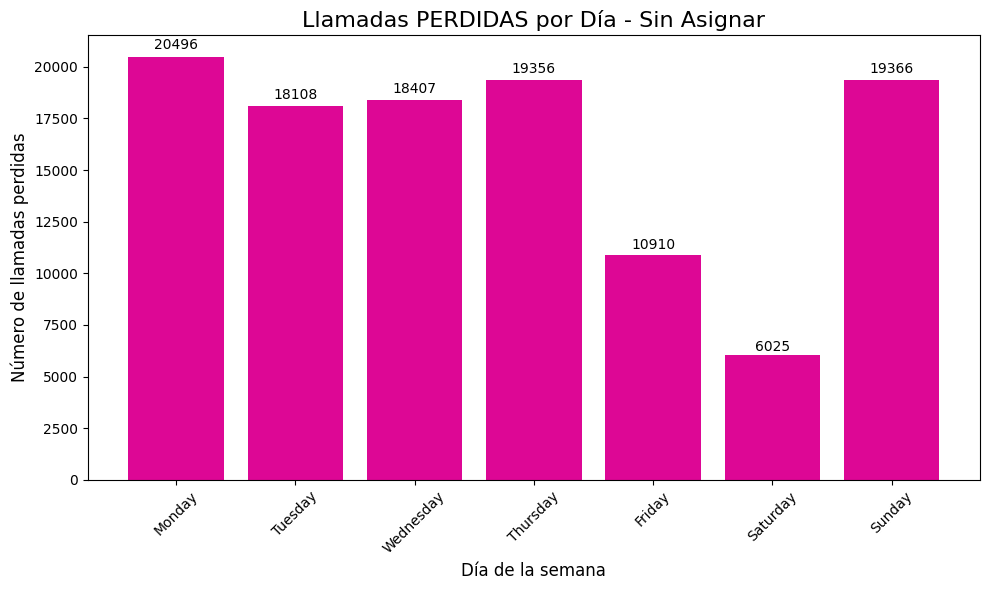

In [25]:
# Se crea gráfico de barras para visualizar las llamadas perdidas por día

operador_0_perdidas = operador_0[operador_0['is_missed_call'] == True].copy()


perdidas_by_day = operador_0_perdidas.groupby('day_of_week')['calls_count'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
perdidas_by_day = perdidas_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(perdidas_by_day.index, perdidas_by_day.values, color='#DD0795')


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Llamadas PERDIDAS por Día - Sin Asignar', fontsize=16)
plt.xlabel('Día de la semana', fontsize=12)
plt.ylabel('Número de llamadas perdidas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



En esta gráfica de barras podemos validar que el patron de llamadas no asiganadas se mantiene con las llamadas perdidas.

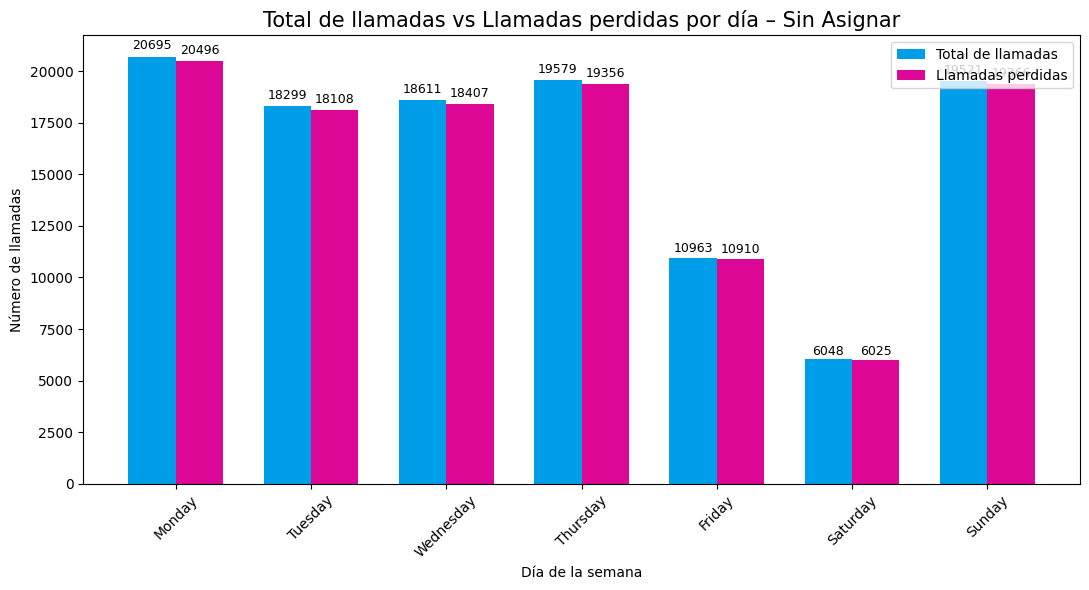

In [26]:
#Se crea gráfico para visializar total de llamadas al lado de las llamadas perdidas

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

calls_by_day = calls_by_day.reindex(day_order)
perdidas_by_day = perdidas_by_day.reindex(day_order)

x = np.arange(len(day_order))  
width = 0.35                   

plt.figure(figsize=(11, 6))

bars_total = plt.bar(
    x - width/2,
    calls_by_day.values,
    width,
    label='Total de llamadas',
    color='#009EE8'
)

bars_lost = plt.bar(
    x + width/2,
    perdidas_by_day.values,
    width,
    label='Llamadas perdidas',
    color='#DD0795'
)

for bars in [bars_total, bars_lost]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + height * 0.01,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.title('Total de llamadas vs Llamadas perdidas por día – Sin Asignar', fontsize=15)
plt.xlabel('Día de la semana')
plt.ylabel('Número de llamadas')
plt.xticks(x, day_order, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

En el gráfico de barras agrupadas podemos comparar de forma directa el volumen total de llamadas frente a las llamadas perdidas por día, facilitando la identificación de patrones de ineficiencia operativa en días específicos.

Esto nos da un indicio que estos días y en este horario es en donde no hay suficientes operadores conectados para atender las llamadas, esto se entregará en la presentación que entregará al cliente para hacer una recomendación sobre el horarios de atención.

In [27]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   user_id              53902 non-null  int64              
 1   date                 53902 non-null  datetime64[ns, UTC]
 2   year                 53902 non-null  int64              
 3   month                53902 non-null  int64              
 4   day                  53902 non-null  int64              
 5   direction            53902 non-null  object             
 6   internal             53902 non-null  object             
 7   operator_id          53902 non-null  Int64              
 8   is_missed_call       53902 non-null  bool               
 9   calls_count          53902 non-null  int64              
 10  call_duration        53902 non-null  int64              
 11  hold_time            53902 non-null  int64              
 12  total_call_duratio

In [28]:
# Verificar el volumen total de llamadas en esos momentos críticos
critical_times = telecom[
    ((telecom['date'].dt.day_name() == 'Monday') | 
     (telecom['date'].dt.day_name() == 'Thursday') | 
     (telecom['date'].dt.day_name() == 'Sunday')) & 
    (telecom['date'].dt.hour == 21)
]

print(f"Volumen total de llamadas en horarios críticos: {len(critical_times)}")
print(f"Porcentaje del total de llamadas: {len(critical_times)/len(telecom)*100:.1f}%")

Volumen total de llamadas en horarios críticos: 28054
Porcentaje del total de llamadas: 52.0%


Al analizar las llamadas no asignadas y perdidas no asignadas nos cuentan una historia muy importante. Más de la mitad de todas las llamadas se concentran en momentos críticos (**lunes**, **jueves** y **domingos** a las **21:00**). Esto es una señal clara de un problema sistémico.

In [29]:
#Se calculan métriscas por operador

operator_metrics = telecom.groupby('operator_id').agg({
    'is_missed_call': ['count', 'sum'],
    'hold_time': 'mean',
    'direction': lambda x: (x == 'out').sum()
}).round(2)


operator_metrics.columns = ['total_calls', 'missed_calls', 'avg_hold_time', 'outgoing_calls']

operator_metrics['missed_call_rate'] = (operator_metrics['missed_calls'] / operator_metrics['total_calls'] * 100).round(2)

print("Primeras métricas por operador:")
operator_metrics.head()

Primeras métricas por operador:


,total_calls,missed_calls,avg_hold_time,outgoing_calls,missed_call_rate
operator_id,,,,,
0,8172,8050,167.74,200,98.51
879896,128,50,110.67,105,39.06
879898,251,100,450.09,187,39.84
880020,22,7,15.18,14,31.82
880022,76,33,57.57,68,43.42


In [30]:
#Se excluye al operador 0 de los cálculos

real_operators_metrics = operator_metrics[operator_metrics.index != 0].copy()

print("=== ESTADÍSTICAS SIN OPERADOR 0 ===")
print(f"Total operadores reales: {len(real_operators_metrics)}")
print(f"Tasa de llamadas perdidas - Media: {real_operators_metrics['missed_call_rate'].mean():.1f}%")
print(f"Percentil 60: {real_operators_metrics['missed_call_rate'].quantile(0.60):.1f}%")
print(f"Percentil 70: {real_operators_metrics['missed_call_rate'].quantile(0.70):.1f}%")

print(f"\nTiempo de espera - Media: {real_operators_metrics['avg_hold_time'].mean():.1f}s")
print(f"Percentil 60: {real_operators_metrics['avg_hold_time'].quantile(0.60):.1f}s")
print(f"Percentil 70: {real_operators_metrics['avg_hold_time'].quantile(0.70):.1f}s")

print(f"\nLlamadas salientes - Media: {real_operators_metrics['outgoing_calls'].mean():.1f}")
print(f"Percentil 30: {real_operators_metrics['outgoing_calls'].quantile(0.30):.1f}")
print(f"Percentil 40: {real_operators_metrics['outgoing_calls'].quantile(0.40):.1f}")


=== ESTADÍSTICAS SIN OPERADOR 0 ===
Total operadores reales: 1092
Tasa de llamadas perdidas - Media: 31.4%
Percentil 60: 37.1%
Percentil 70: 43.2%

Tiempo de espera - Media: 215.4s
Percentil 60: 65.0s
Percentil 70: 121.2s

Llamadas salientes - Media: 29.0
Percentil 30: 2.0
Percentil 40: 6.0


A
l analizar de los resultados opodemos tener las siguientes conclusiones:

*Operador 0* - Confirmamos el problema técnico de las llamadas sin asignar:
-El **98.51%** de llamadas perdidas no se asiganron a ningún operador
- **8,172** llamadas totales, esto es un volumen muy alto 
- Esto confirma la hipótesis sobre problemas técnicos del sistema

Para evitar sesgar la información y hacer la identificación adecuada de operadores ineficaces se tomo la decisión de no incluirlo en los calculos subsecuentes. 

Patrones interesantes en las estadísticas:
- La media de llamadas perdidas: **31.4%** vs Percentil 70: **43.2%**
- La media del tiempo en espera: **215.4s** vs Percentil 70: **121.2s**

Despúes de realizar el análisis se proponen los siguientes umbrales para identificar a los operadores ineficaces:


In [31]:
##Se definen umbrales basados en los percentiles (percentiles 60-70)

print("\n=== UMBRALES (Percentil 60 - 70) ===")
missed_call_threshold_new = real_operators_metrics['missed_call_rate'].quantile(0.70)
hold_time_threshold_new = real_operators_metrics['avg_hold_time'].quantile(0.70)
outgoing_calls_threshold_new = real_operators_metrics['outgoing_calls'].quantile(0.30)

print(f"Umbral llamadas perdidas: >{missed_call_threshold_new:.1f}%")
print(f"Umbral tiempo de espera: >{hold_time_threshold_new:.1f}s")
print(f"Umbral llamadas salientes: <{outgoing_calls_threshold_new:.1f}")


=== UMBRALES (Percentil 60 - 70) ===
Umbral llamadas perdidas: >43.2%
Umbral tiempo de espera: >121.2s
Umbral llamadas salientes: <2.0


In [32]:
print("=== IDENTIFICACIÓN UMBRALES ===")

inefficient_operators_new = real_operators_metrics[
    (real_operators_metrics['missed_call_rate'] > 43.2) &
    (real_operators_metrics['avg_hold_time'] > 121.2) &
    (real_operators_metrics['outgoing_calls'] < 2.0)
]

print(f"Operadores que cumplen LOS 3 criterios: {len(inefficient_operators_new)}")
if len(inefficient_operators_new) > 0:
    print(inefficient_operators_new[['missed_call_rate', 'avg_hold_time', 'outgoing_calls', 'total_calls']])

print("\n=== ANÁLISIS POR COMBINACIONES ===")
combo1_new = real_operators_metrics[
    (real_operators_metrics['missed_call_rate'] > 43.2) &
    (real_operators_metrics['avg_hold_time'] > 121.2)
]
print(f"Perdidas altas + Tiempo alto: {len(combo1_new)} operadores")

combo2_new = real_operators_metrics[
    (real_operators_metrics['missed_call_rate'] > 43.2) &
    (real_operators_metrics['outgoing_calls'] < 2.0)
]
print(f"Perdidas altas + Pocas salientes: {len(combo2_new)} operadores")

=== IDENTIFICACIÓN UMBRALES ===
Operadores que cumplen LOS 3 criterios: 0

=== ANÁLISIS POR COMBINACIONES ===
Perdidas altas + Tiempo alto: 177 operadores
Perdidas altas + Pocas salientes: 35 operadores


Al excluir las llamadas sin asiganar podemos identificar que no hay operadores que cumplan los tres criterios simultáneamente. Esto nos está indicando algo importante sobre la naturaleza de los problemas de eficiencia.

Parece que los problemas de los operadores tienden a ser específicos más que generales. Esto puede ser muy valioso para *CallMeMaybe* porque significa que pueden enfocar las mejoras de manera más dirigida.

Después de analizar esta información creemos pertinente aconsejar a la empresa categorizar a los operadores por tipo de problema en lugar de buscar un "operador problemático general".

La propuesta es crear tres categorías de operadores ineficaces:

1. Problemas de gestión de llamadas (perdidas + tiempo)
2. Problemas de proactividad (perdidas + pocas salientes)  
3. Problemas de seguimiento (tiempo + pocas salientes)

In [33]:
#Se establecen valores de llamadas y días activos para poder obtener información apegada a la realidad

volumen_minimo = 10  # Más conservador que el percentil 25 (6)
dias_minimos = 3     # Basado en el percentil 25 (3.75)

#Se aplica el filtro
print("=== APLICANDO FILTRO COMBINADO ===")
print(f"Criterios: ≥{volumen_minimo} llamadas Y ≥{dias_minimos} días activos")

operator_activity = telecom.groupby('operator_id')['date'].nunique().reset_index()
operator_activity.columns = ['operator_id', 'dias_activos']
operator_activity = operator_activity.set_index('operator_id')

operators_filtered = real_operators_metrics.merge(
    operator_activity[['dias_activos']],
    left_index=True,
    right_index=True
)

operators_qualified = operators_filtered[
    (operators_filtered['total_calls'] >= volumen_minimo) &
    (operators_filtered['dias_activos'] >= dias_minimos)
]

print(f"Operadores antes del filtro: {len(real_operators_metrics)}")
print(f"Operadores después del filtro: {len(operators_qualified)}")


=== APLICANDO FILTRO COMBINADO ===
Criterios: ≥10 llamadas Y ≥3 días activos
Operadores antes del filtro: 1092
Operadores después del filtro: 713


Despúes de hacer el análisis identificamos que 35 operadores aparecían como ineficientes en problemas de proactividad pero tenían pocas llamadas y pocos días actividad.

Se decidieron retirar ya que esos operadores representan operadores nuevos o en su curva de aprendizaje y es por ello que no es justo clasificarlos como operadores ineficaces por es tema, si se recomienda hacer un seguimiento despues de transcurrir su curva para validar que hayan mejorado sus métricas.

In [34]:
print("=== CATEGORIZACIÓN DE OPERADORES INEFICACES ===")

# Categoría 1: Problemas de gestión de llamadas
gestion_problemas = operators_qualified[
    (operators_qualified['missed_call_rate'] > 43.2) &
    (operators_qualified['avg_hold_time'] > 121.2)
]

# Categoría 2: Problemas de proactividad   
proactividad_problemas = operators_qualified[
    (operators_qualified['missed_call_rate'] > 43.2) &
    (operators_qualified['outgoing_calls'] < 2.0)
]

# Categoría 3: Problemas de seguimiento
seguimiento_problemas = operators_qualified[
    (operators_qualified['avg_hold_time'] > 121.2) &
    (operators_qualified['outgoing_calls'] < 2.0)
]

print(f"📞 GESTIÓN DE LLAMADAS (perdidas altas + tiempo alto): {len(gestion_problemas)} operadores")
print(f"🎯 PROACTIVIDAD (perdidas altas + pocas salientes): {len(proactividad_problemas)} operadores") 
print(f"📋 SEGUIMIENTO (tiempo alto + pocas salientes): {len(seguimiento_problemas)} operadores")

print("\n=== EJEMPLOS DE CADA CATEGORÍA ===")
print("\n📞 GESTIÓN DE LLAMADAS (Top 5 más problemáticos):")
print(gestion_problemas.nlargest(5, 'missed_call_rate')[['missed_call_rate', 'avg_hold_time', 'total_calls']])

print("\n🎯 PROACTIVIDAD (Top 5 más problemáticos):")
if len(proactividad_problemas) > 0:
    print(proactividad_problemas.nlargest(5, 'missed_call_rate')[['missed_call_rate', 'outgoing_calls', 'total_calls']])
else:
    print("No hay operadores en esta categoría después del filtro")

    print("\n📋 SEGUIMIENTO (Top 5 más problemáticos):")
if len(seguimiento_problemas) > 0:
    print(seguimiento_problemas.nlargest(5, 'avg_hold_time')[['avg_hold_time', 'outgoing_calls', 'total_calls']])
else:
    print("No hay operadores en esta categoría después del filtro")

=== CATEGORIZACIÓN DE OPERADORES INEFICACES ===
📞 GESTIÓN DE LLAMADAS (perdidas altas + tiempo alto): 159 operadores
🎯 PROACTIVIDAD (perdidas altas + pocas salientes): 0 operadores
📋 SEGUIMIENTO (tiempo alto + pocas salientes): 2 operadores

=== EJEMPLOS DE CADA CATEGORÍA ===

📞 GESTIÓN DE LLAMADAS (Top 5 más problemáticos):
             missed_call_rate  avg_hold_time  total_calls
operator_id                                              
945728                  72.73         220.82           11
953462                  67.65         394.15           34
952468                  65.85         512.73           41
952458                  65.00         874.20           40
902744                  62.07         659.63           87

🎯 PROACTIVIDAD (Top 5 más problemáticos):
No hay operadores en esta categoría después del filtro

📋 SEGUIMIENTO (Top 5 más problemáticos):
             avg_hold_time  outgoing_calls  total_calls
operator_id                                            
919206         

Con este enfoque de categorización permitirá a CallMeMaybe:

- Entrenamientos específicos para cada tipo de problema
- Métricas de seguimiento más precisas
- Planes de mejora personalizados

Al realizar el análisis con este categorización tuvimos algunos hallazgos clave los cuales categorizamos por prioridad de acuerdo a las métricas de la empresa y de la industria:

🔴 PRIORIDAD ALTA - Gestión de Llamadas (159 operadores)
 - Es el problema más extendido
 - Operadores que pierden muchas llamadas Y tienen tiempos de espera altos
 - Indica problemas de capacidad de atención y gestión del tiempo

🟢 PRIORIDAD BAJA - Seguimiento (2 operadores)
 - Problema menos común
 - Tiempos altos pero pocas llamadas salientes

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, los criterios para identificar el desempeño de los operadores quedó súper claro y está basado totalmente en los datos análizados lo cual demuestra un gran dominio y capacidad de análisis
</div>

In [35]:
#Se analizan los resultadis de los operadires con problemas de gestión de llamadas

print("=== ANÁLISIS DETALLADO: OPERADORES DE GESTIÓN ===")

print(f"Total de operadores GESTIÓN: {len(gestion_problemas)}")
print(f"Porcentaje del total filtrado: {len(gestion_problemas)/len(operators_qualified)*100:.1f}%")

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS:")
print("Tasa de llamadas perdidas:")
print(f"  - Promedio: {gestion_problemas['missed_call_rate'].mean():.1f}%")
print(f"  - Mediana: {gestion_problemas['missed_call_rate'].median():.1f}%")
print(f"  - Rango: {gestion_problemas['missed_call_rate'].min():.1f}% - {gestion_problemas['missed_call_rate'].max():.1f}%")

print("\nTiempo de espera promedio:")
print(f"  - Promedio: {gestion_problemas['avg_hold_time'].mean():.1f}s")
print(f"  - Mediana: {gestion_problemas['avg_hold_time'].median():.1f}s")
print(f"  - Rango: {gestion_problemas['avg_hold_time'].min():.1f}s - {gestion_problemas['avg_hold_time'].max():.1f}s")

print("\nVolumen de llamadas:")
print(f"  - Promedio: {gestion_problemas['total_calls'].mean():.1f}")
print(f"  - Mediana: {gestion_problemas['total_calls'].median():.1f}")
print(f"  - Rango: {gestion_problemas['total_calls'].min()} - {gestion_problemas['total_calls'].max()}")

=== ANÁLISIS DETALLADO: OPERADORES DE GESTIÓN ===
Total de operadores GESTIÓN: 159
Porcentaje del total filtrado: 22.3%

📊 ESTADÍSTICAS DESCRIPTIVAS:
Tasa de llamadas perdidas:
  - Promedio: 50.3%
  - Mediana: 50.0%
  - Rango: 43.2% - 72.7%

Tiempo de espera promedio:
  - Promedio: 876.2s
  - Mediana: 694.9s
  - Rango: 122.1s - 5325.3s

Volumen de llamadas:
  - Promedio: 48.5
  - Mediana: 40.0
  - Rango: 10 - 290


Hallazgos Clave de los 159 Operadores de GESTIÓN

Magnitud del Problema
- **22.3%** de todos los operadores calificados tienen problemas de gestión
- Esto confirma que es el problema más extendido en CallMeMaybe

Patrones Críticos Identificados

1. 📞 Tasa de Llamadas Perdidas:
- Promedio: **50.3%** (vs umbral de **43.2%**)
- Rango: **43.2%** - **72.7%** - **¡Algunos operadores pierden 7 de cada 10 llamadas!**

2. ⏱️ Tiempo de Espera:
- Promedio: 876 segundos (14.6 minutos)
- Mediana: 695 segundos (11.6 minutos)
- Máximo: **5,325 segundos** (88.8 minutos) - **¡Casi 1.5 horas de espera!**

3. 📊 Volumen de Llamadas:
- Rango muy amplio: 10 - 290 llamadas
- Sugiere que el problema afecta tanto a operadores con poco como mucho volumen

In [36]:
#Se calcula correlaciones

print("=== CORRELACIÓN: VOLUMEN vs SEVERIDAD DEL PROBLEMA ===")

corr_calls_missed = gestion_problemas['total_calls'].corr(gestion_problemas['missed_call_rate'])
corr_calls_hold = gestion_problemas['total_calls'].corr(gestion_problemas['avg_hold_time'])

print(f"📊 CORRELACIONES:")
print(f"Volumen vs Tasa de llamadas perdidas: {corr_calls_missed:.3f}")
print(f"Volumen vs Tiempo de espera: {corr_calls_hold:.3f}")


print("\n📈 ANÁLISIS POR SEGMENTOS DE VOLUMEN:")

bajo_volumen = gestion_problemas[gestion_problemas['total_calls'] <= 30]
medio_volumen = gestion_problemas[(gestion_problemas['total_calls'] > 30) & (gestion_problemas['total_calls'] <= 60)]
alto_volumen = gestion_problemas[gestion_problemas['total_calls'] > 60]

print(f"\n🔹 BAJO VOLUMEN (≤30 llamadas): {len(bajo_volumen)} operadores")
print(f"  - Tasa perdidas promedio: {bajo_volumen['missed_call_rate'].mean():.1f}%")
print(f"  - Tiempo espera promedio: {bajo_volumen['avg_hold_time'].mean():.1f}s")

print(f"\n🔸 MEDIO VOLUMEN (31-60 llamadas): {len(medio_volumen)} operadores")
print(f"  - Tasa perdidas promedio: {medio_volumen['missed_call_rate'].mean():.1f}%")
print(f"  - Tiempo espera promedio: {medio_volumen['avg_hold_time'].mean():.1f}s")

print(f"\n🔺 ALTO VOLUMEN (>60 llamadas): {len(alto_volumen)} operadores")
print(f"  - Tasa perdidas promedio: {alto_volumen['missed_call_rate'].mean():.1f}%")
print(f"  - Tiempo espera promedio: {alto_volumen['avg_hold_time'].mean():.1f}s")

=== CORRELACIÓN: VOLUMEN vs SEVERIDAD DEL PROBLEMA ===
📊 CORRELACIONES:
Volumen vs Tasa de llamadas perdidas: -0.121
Volumen vs Tiempo de espera: -0.171

📈 ANÁLISIS POR SEGMENTOS DE VOLUMEN:

🔹 BAJO VOLUMEN (≤30 llamadas): 52 operadores
  - Tasa perdidas promedio: 50.3%
  - Tiempo espera promedio: 857.6s

🔸 MEDIO VOLUMEN (31-60 llamadas): 71 operadores
  - Tasa perdidas promedio: 50.2%
  - Tiempo espera promedio: 948.4s

🔺 ALTO VOLUMEN (>60 llamadas): 36 operadores
  - Tasa perdidas promedio: 50.3%
  - Tiempo espera promedio: 760.8s


Correlaciones Débiles y Negativas

- Volumen vs Llamadas perdidas: -0.121 (correlación débil negativa)
- Volumen vs Tiempo de espera: -0.171 (correlación débil negativa)

¿Qué Significa Esto?
📍 Interpretación Principal:
- NO es un problema de sobrecarga de trabajo
- Los operadores con más volumen **NO** tienen peores métricas
- De hecho, hay una ligera tendencia a que operadores con más volumen tengan mejores métricas

Análisis por Segmentos - Patrón Interesante
🔹 Tasa de Llamadas Perdidas: Prácticamente idéntica en todos los segmentos (~50.3%)

⏱️ Tiempo de Espera: Patrón en "U invertida"
- Bajo volumen: 857.6s
- Medio volumen: 948.4s (el peor)
- Alto volumen: 760.8s (el mejor)
🎯 Evidencia que Confirma tu Hipótesis
1. Correlaciones Débiles y Negativas:

Volumen vs Llamadas perdidas: -0.121
Volumen vs Tiempo de espera: -0.171

Esto demuestra que NO es sobrecarga de trabajo - los operadores con más llamadas no tienen peor desempeño.

2. Patrón Consistente en Todos los Segmentos:

Tasa de llamadas perdidas **~50.3%** en todos los volúmenes
Sugiere un problema sistemático de habilidades


## Parte 3. Prueba de hipótesis

#### Definición de Hipótesis

- Hipótesis Nula (H₀): No hay diferencia significativa en las métricas entre operadores de gestión y otros operadores

- Hipótesis Alternativa (H₁): Sí hay diferencia significativa entre los grupos

In [37]:
#Se crean grupos para comparación

print("=== PREPARACIÓN DE GRUPOS PARA ANOVA ===")

# Grupo 1: Operadores de gestión (problemas)
gestion_ids = gestion_problemas.index.tolist()

# Grupo 2: Otros operadores (sin problemas de gestión)
otros_operadores = operators_qualified[~operators_qualified.index.isin(gestion_ids)]

print(f"Operadores de GESTIÓN: {len(gestion_problemas)}")
print(f"Otros operadores: {len(otros_operadores)}")

#Se extraen métricas para cada grupo

gestion_missed_rate = gestion_problemas['missed_call_rate']
otros_missed_rate = otros_operadores['missed_call_rate']

gestion_hold_time = gestion_problemas['avg_hold_time']
otros_hold_time = otros_operadores['avg_hold_time']

gestion_outgoing = gestion_problemas['outgoing_calls']
otros_outgoing = otros_operadores['outgoing_calls']

=== PREPARACIÓN DE GRUPOS PARA ANOVA ===
Operadores de GESTIÓN: 159
Otros operadores: 554


In [38]:
print("=== PRUEBAS DE HIPÓTESIS: ANOVA ===")
print("H₀: No hay diferencia significativa entre operadores de gestión y otros operadores")
print("H₁: Sí hay diferencia significativa entre los grupos")
print("Nivel de significancia: α = 0.05\n")

# Crear grupos para comparación
gestion_ids = gestion_problemas.index.tolist()
otros_operadores = operators_qualified[~operators_qualified.index.isin(gestion_ids)]

print(f"Operadores de GESTIÓN: {len(gestion_problemas)}")
print(f"Otros operadores: {len(otros_operadores)}")

# Definir las métricas a comparar
metricas = ['missed_call_rate', 'avg_hold_time', 'outgoing_calls', 'total_calls']

# Realizar ANOVA para cada métrica
resultados_anova = {}

print("\n=== RESULTADOS DE ANOVA POR MÉTRICA ===")

for metrica in metricas:
    # Extraer datos de cada grupo
    grupo_gestion = gestion_problemas[metrica]
    grupo_otros = otros_operadores[metrica]
    
    # Realizar ANOVA de una vía
    f_stat, p_value = stats.f_oneway(grupo_gestion, grupo_otros)
    
    # Guardar resultados
    resultados_anova[metrica] = {
        'F_statistic': f_stat,
        'p_value': p_value,
        'significativo': p_value < 0.05
    }
    
    # Mostrar resultados
    print(f"\n📊 {metrica.upper()}:")
    print(f"   F-statistic: {f_stat:.4f}")
    print(f"   p-value: {p_value:.6f}")
    print(f"   ¿Significativo? {'SÍ' if p_value < 0.05 else 'NO'}")
    
    if p_value < 0.05:
        print(f"   ✅ Rechazamos H₀: HAY diferencia significativa")
    else:
        print(f"   ❌ No rechazamos H₀: NO hay diferencia significativa")

=== PRUEBAS DE HIPÓTESIS: ANOVA ===
H₀: No hay diferencia significativa entre operadores de gestión y otros operadores
H₁: Sí hay diferencia significativa entre los grupos
Nivel de significancia: α = 0.05

Operadores de GESTIÓN: 159
Otros operadores: 554

=== RESULTADOS DE ANOVA POR MÉTRICA ===

📊 MISSED_CALL_RATE:
   F-statistic: 367.5004
   p-value: 0.000000
   ¿Significativo? SÍ
   ✅ Rechazamos H₀: HAY diferencia significativa

📊 AVG_HOLD_TIME:
   F-statistic: 268.3325
   p-value: 0.000000
   ¿Significativo? SÍ
   ✅ Rechazamos H₀: HAY diferencia significativa

📊 OUTGOING_CALLS:
   F-statistic: 1.0132
   p-value: 0.314483
   ¿Significativo? NO
   ❌ No rechazamos H₀: NO hay diferencia significativa

📊 TOTAL_CALLS:
   F-statistic: 11.4730
   p-value: 0.000745
   ¿Significativo? SÍ
   ✅ Rechazamos H₀: HAY diferencia significativa


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre se debe realizar pruebas estadísticas para determinar si las diferencias observadas son significativas y no se está sesgando el análisis
</div>

## Parte 4. Conclusiones

Después de plantear la hipótesis nula y la hipótesis alternativa, se pueden destacar los siguientes hallazgos:

El volumen de llamadas salientes no presenta diferencias estadísticamente significativas entre los grupos analizados. Tal como se observó en el análisis exploratorio, esta métrica es consistentemente baja en todos los operadores, con una media aproximada de **29 llamadas salientes**. Esto explica que no se hayan encontrado diferencias significativas en esta variable (p-value = **0.314**).

Con base en los resultados del *ANOVA*, se confirma que los operadores clasificados como ineficaces en la gestión de llamadas presentan problemas significativos y claras áreas de oportunidad en las siguientes métricas:

Tasa de llamadas perdidas (Missed Call Rate) (p < 0.001):
- Promedio de **50.3%**, significativamente superior al del resto de los operadores.

Tiempo promedio de espera (Average Hold Time) (p < 0.001):
 - Promedio de **876** segundos, lo que indica demoras sustanciales en la atención.

Volumen total de llamadas atendidas (Total Calls) (p < 0.001):
 - Se observan diferencias significativas en la capacidad de manejo de llamadas frente a otros operadores.

Para este grupo de operadores, se recomienda implementar sesiones de capacitación (*uptraining*) enfocadas en:

 - Manejo y uso eficiente del sistema
 - Técnicas de atención y gestión de llamadas
 - Talleres de comunicación efectiva
 - Manejo de llamadas difíciles y clientes complejos, entre otros

In [39]:
#Se realiza análisis de Subgrupos para Estrategias Dirigidas

print("=== SEGMENTACIÓN CORREGIDA DE OPERADORES DE GESTIÓN ===")

gestion_analisis = gestion_problemas.copy()

# Crear subgrupos basados en severidad del problema
gestion_analisis['severidad_perdidas'] = pd.cut(
    gestion_analisis['missed_call_rate'], 
    bins=[0, 50, 60, 100], 
    labels=['Moderado', 'Alto', 'Crítico']
)

gestion_analisis['severidad_tiempo'] = pd.cut(
    gestion_analisis['avg_hold_time'], 
    bins=[0, 600, 1200, 10000], 
    labels=['Moderado', 'Alto', 'Crítico']
)

# Mostrar resultados
print("📊 DISTRIBUCIÓN POR SEVERIDAD:")
print("\n🔴 Severidad en LLAMADAS PERDIDAS:")
print(gestion_analisis['severidad_perdidas'].value_counts())

print("\n⏱️ Severidad en TIEMPO DE ESPERA:")
print(gestion_analisis['severidad_tiempo'].value_counts())

# Crear matriz de combinaciones
combinaciones = pd.crosstab(
    gestion_analisis['severidad_perdidas'], 
    gestion_analisis['severidad_tiempo'], 
    margins=True
)
print("\n🎯 MATRIZ DE COMBINACIONES:")
print(combinaciones)

=== SEGMENTACIÓN CORREGIDA DE OPERADORES DE GESTIÓN ===
📊 DISTRIBUCIÓN POR SEVERIDAD:

🔴 Severidad en LLAMADAS PERDIDAS:
Moderado    97
Alto        56
Crítico      6
Name: severidad_perdidas, dtype: int64

⏱️ Severidad en TIEMPO DE ESPERA:
Moderado    72
Crítico     46
Alto        41
Name: severidad_tiempo, dtype: int64

🎯 MATRIZ DE COMBINACIONES:
severidad_tiempo    Moderado  Alto  Crítico  All
severidad_perdidas                              
Moderado                  49    22       26   97
Alto                      20    16       20   56
Crítico                    3     3        0    6
All                       72    41       46  159


A partir de la segmentación corregida de los operadores de gestión, se identificaron distintos niveles de severidad en las métricas críticas de desempeño: **llamadas perdidas** y **tiempo de espera**, lo que permite una caracterización más precisa del grado de ineficiencia operativa.

En la métrica de **llamadas perdidas**, la mayoría de los operadores se concentra en un nivel de severidad **moderado** (**97 operadores**), seguido por un grupo relevante con severidad **alta** (**56 operadores**) y un subconjunto reducido pero crítico de operadores con severidad **crítica** (**6 operadores**). Este último grupo, aunque numéricamente pequeño, representa un riesgo operativo importante debido al impacto directo en la experiencia del cliente.

Respecto al **tiempo de espera**, se observa una distribución más dispersa entre los niveles de severidad, con **72 operadores** en nivel **moderado**, **41** en nivel **alto** y **46** en nivel **crítico**. Esto indica que los problemas relacionados con la demora en la atención son más frecuentes y están más extendidos entre los operadores de gestión que las llamadas perdidas.

El análisis de la matriz de combinaciones de severidad permite identificar patrones clave. Una proporción significativa de operadores presenta niveles elevados en ambas métricas, lo que sugiere que **las ineficiencias no ocurren de forma aislada**, sino que tienden a manifestarse simultáneamente en múltiples dimensiones del desempeño. Este hallazgo **refuerza la hipótesis de que los problemas observados están relacionados con fallas estructurales en la gestión de llamadas**, y no únicamente con casos individuales o eventos puntuales.

En particular, **la existencia de operadores con severidad crítica en al menos una de las métricas evidencia la necesidad de intervenciones diferenciadas**, ya que no todos los operadores requieren el mismo nivel de acción correctiva. Mientras que los casos moderados pueden abordarse mediante ajustes operativos y capacitación ligera, los casos altos y críticos demandan planes de mejora más intensivos y seguimiento cercano.

En conjunto, esta segmentación permite priorizar esfuerzos de manera estratégica, enfocando recursos en los operadores con mayor impacto negativo potencial, y sienta las bases para la implementación de planes de capacitación, monitoreo y mejora continua basados en datos.

A partir del análisis detallado de las métricas críticas de desempeño —**tasa de llamadas perdidas** y **tiempo promedio de espera**— se identificó un subconjunto de operadores que presentan niveles críticos de ineficiencia operativa, los cuales requieren atención prioritaria.

En la métrica de **llamadas perdidas**, se detectaron **6 operadores** con valores significativamente elevados, alcanzando tasas superiores al **60%**, e incluso cercanas al **70%**. Estos niveles indican una incapacidad sostenida para atender llamadas entrantes de forma efectiva, lo que tiene un impacto directo y negativo en la experiencia del cliente. Adicionalmente, se observa que varios de estos operadores presentan volúmenes bajos de llamadas atendidas, lo que sugiere una combinación de baja capacidad operativa y alto desperdicio de demanda.

Por otro lado, en la métrica de **tiempo de espera**, se identificaron **46 operadores** con valores críticos, registrando tiempos promedio que superan ampliamente los umbrales aceptables y alcanzan en algunos casos más de una hora de espera. Este comportamiento evidencia problemas estructurales en la gestión de llamadas, uso del sistema o priorización de tareas, y representa una de las principales fuentes de fricción para los clientes.

El análisis conjunto de ambas métricas revela que, aunque no todos los operadores críticos en tiempo de espera presentan las tasas más altas de llamadas perdidas, sí existe un patrón consistente de ineficiencia en la atención de llamadas entrantes, caracterizado por demoras prolongadas y una alta proporción de llamadas no atendidas. **Esto refuerza la hipótesis de que las ineficiencias no son aisladas, sino que responden a fallas en procesos, habilidades o carga operativa**.

En términos operativos, estos resultados permiten priorizar acciones correctivas de manera focalizada. **Los operadores críticos en ambas métricas deben considerarse como casos de intervención inmediata**, mientras que aquellos críticos únicamente en tiempo de espera pueden beneficiarse de ajustes específicos en el manejo del sistema, distribución de carga o capacitación técnica.

Finalmente, la identificación puntual de estos operadores proporciona una base sólida para implementar planes de mejora individualizados, establecer metas de desempeño claras y realizar un seguimiento continuo, con el objetivo de reducir la pérdida de llamadas, optimizar los tiempos de espera y mejorar de forma sostenida la calidad del servicio.

In [40]:
#Se identifican a los operadores encontrados como criticos para poder trabajar puntalmente con ellos

print("=== IDENTIFICACIÓN DE OPERADORES CRÍTICOS ===")

# Identificar los 6 operadores críticos en llamadas perdidas
criticos_perdidas = gestion_analisis[gestion_analisis['severidad_perdidas'] == 'Crítico']
print("🔴 OPERADORES CRÍTICOS EN LLAMADAS PERDIDAS (6 operadores):")
print("Operator_ID | Missed_Call_Rate | Avg_Hold_Time | Total_Calls")
print("-" * 60)
for idx, row in criticos_perdidas.iterrows():
    print(f"{idx:11} | {row['missed_call_rate']:15.1f}% | {row['avg_hold_time']:12.0f}s | {row['total_calls']:10.0f}")

print("\n" + "="*60)

# Identificar los 46 operadores críticos en tiempo de espera
criticos_tiempo = gestion_analisis[gestion_analisis['severidad_tiempo'] == 'Crítico']
print("⏱️ OPERADORES CRÍTICOS EN TIEMPO DE ESPERA (46 operadores):")
print("Operator_ID | Missed_Call_Rate | Avg_Hold_Time | Total_Calls")
print("-" * 60)
for idx, row in criticos_tiempo.iterrows():
    print(f"{idx:11} | {row['missed_call_rate']:15.1f}% | {row['avg_hold_time']:12.0f}s | {row['total_calls']:10.0f}")

=== IDENTIFICACIÓN DE OPERADORES CRÍTICOS ===
🔴 OPERADORES CRÍTICOS EN LLAMADAS PERDIDAS (6 operadores):
Operator_ID | Missed_Call_Rate | Avg_Hold_Time | Total_Calls
------------------------------------------------------------
     902744 |            62.1% |          660s |         87
     902746 |            61.0% |          662s |         82
     945728 |            72.7% |          221s |         11
     952458 |            65.0% |          874s |         40
     952468 |            65.8% |          513s |         41
     953462 |            67.7% |          394s |         34

⏱️ OPERADORES CRÍTICOS EN TIEMPO DE ESPERA (46 operadores):
Operator_ID | Missed_Call_Rate | Avg_Hold_Time | Total_Calls
------------------------------------------------------------
     908640 |            46.1% |         3456s |         52
     919162 |            54.5% |         1929s |         33
     919188 |            53.9% |         1453s |         13
     919192 |            55.9% |         1314s |  

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance Juan, y las conclusiones son acertadas, sólo hay que realizar unos pequeños ajustes al notebook para culminar con el mismo.
</div>

## Parte 5. Fuentes

- Documentación oficial de pandas
    https://pandas.pydata.org/docs/

Se utilizó para comprender y aplicar operaciones de limpieza, agregación y transformación de datos, como groupby, manejo de valores nulos y creación de métricas por operador.

 - Documentación oficial de NumPy
    https://numpy.org/doc/

Ayudó a realizar cálculos numéricos, trabajar con distribuciones y aplicar operaciones matemáticas necesarias para el análisis de métricas de desempeño.

 - Documentación de SciPy – Módulo scipy.stats
    https://docs.scipy.org/doc/scipy/reference/stats.html

Fue utilizada para seleccionar y aplicar pruebas de hipótesis estadísticas adecuadas, así como para interpretar correctamente los valores p y contrastar hipótesis nula y alternativa.

 - IBM – Call Center Metrics & KPIs
    https://www.ibm.com/topics/call-center-metrics

Proporcionó contexto sobre las métricas más utilizadas para evaluar la eficiencia de operadores de call center, como llamadas perdidas, tiempos de espera y volumen de llamadas.

- Zendesk – Call Center Performance Metrics
    https://www.zendesk.com/blog/call-center-metrics/

Ayudó a validar los criterios utilizados para definir operadores ineficaces y a entender cómo estas métricas se utilizan en entornos reales de atención al cliente.

 - RingCentral – Call Center Metrics That Matter
    https://www.ringcentral.com/call-center-metrics.html

Fue clave para identificar qué indicadores operativos son más relevantes para supervisores, especialmente en relación con llamadas entrantes perdidas y tiempos de espera prolongados.

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Juan!** 

La presentación quedó super clara y muy profesional, la herramienta utilizada da una exposición creativa de los resultados obtenidos en tu análisis. 

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>